#### This code is used for inspecting the viability of the data for RF. Via inspection of this code, smart imputation stratgeies will be developed to hopefully generate models worth using

Below I have modules, the dataset to clean and inspect and code that evaluates completeness

In [2]:
# Load modules

import os
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import scipy.stats as stats 
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import LabelEncoder
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import time
from sklearn.impute import SimpleImputer
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import GroupKFold
from sklearn.impute import KNNImputer
from haversine import haversine
from sklearn.neighbors import BallTree

In [4]:
print("Current working directory:", os.getcwd())
df = pd.read_csv("../../../data/finaldatasets/testdata/xgboost.csv")

Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering


/tmp/ipykernel_9551/3681822695.py:2: DtypeWarning: Columns (6,7,13,14,15,16,17,20,22,23,29,31,33,34,35,36,37,44,45,70,74,75,76) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../data/finaldatasets/testdata/xgboost.csv")


Here to filter the df, to see how complete the reduced dataset may be? 

In [41]:
# data summary table
def summarize_column(col_data):
    numeric_data = pd.to_numeric(col_data, errors='coerce')
    is_numeric = numeric_data.notna().sum() > 0
    return {
        "dtype": col_data.dtype,
        "count": col_data.notna().sum(),
        "pct_complete": round(col_data.notna().mean() * 100, 1),
        "n_unique": col_data.nunique(dropna=True)
    }

# Build summary
summary_long = (
    pd.DataFrame([
        {"variable": col, **summarize_column(df[col])}
        for col in df.columns
    ])
    .sort_values(by="pct_complete", ascending=False)
    .reset_index(drop=True)
)

# Print in markdown table format
from tabulate import tabulate
print(tabulate(
    summary_long,
    headers="keys",
    tablefmt="github",
    showindex=False
))

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   78147 |          100   |      77753 |
| Location.source                                       | object  |   78147 |          100   |          9 |
| year                                                  | int64   |   78147 |          100   |         42 |
| Data.ID                                               | object  |   78147 |          100   |         55 |
| pr_irrigated                                          | float64 |   78143 |          100   |        198 |
| end_date                                              | int64   |   78147 |          100   |         10 |
| start_date                                            | int64   |   78147 |          100   |          7 |
| Grain.yield..tons.ha.1.   

In [13]:
print(f"Shape: {df.shape}")
print(f"Unique countries: {df['Country'].nunique()}")
print(f"Observation years: {df['Observation.period'].min()} - {df['Observation.period'].max()}")
print(df.dtypes.value_counts())


Shape: (78147, 95)
Unique countries: 39
Observation years: 1980 - 2022
float64    59
object     31
int64       5
Name: count, dtype: int64


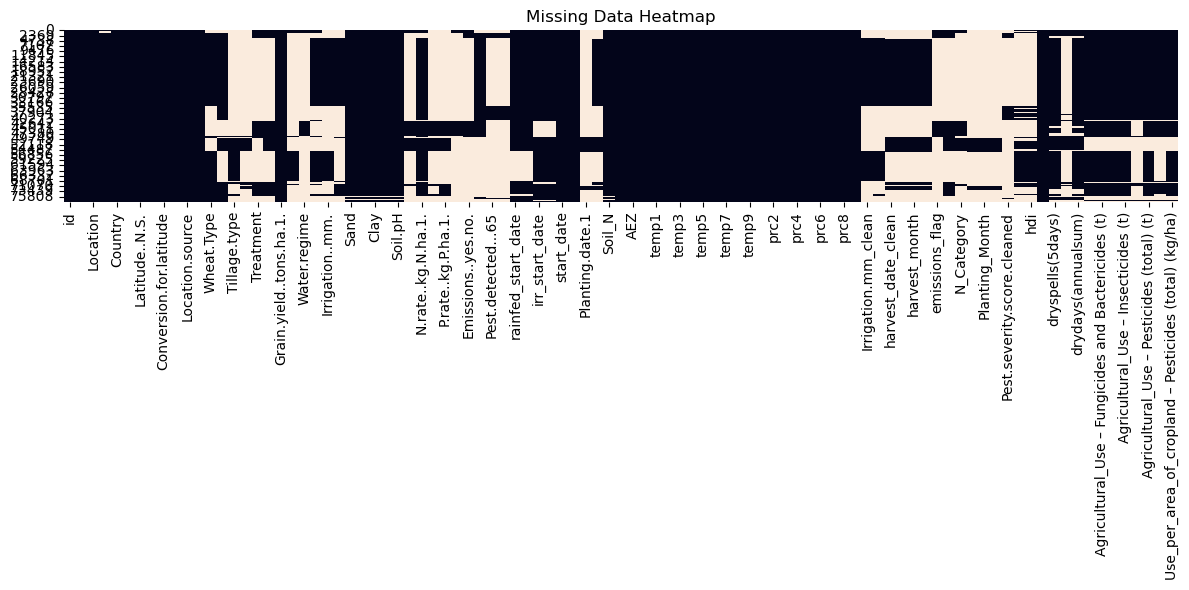

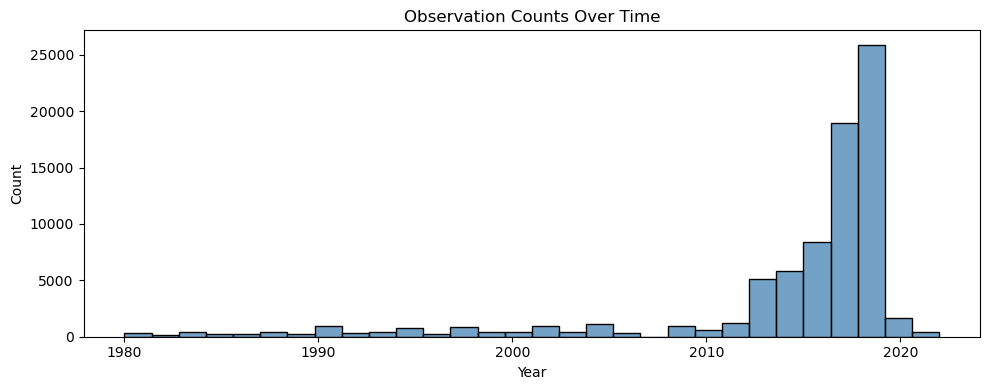

In [14]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(df['Observation.period'], bins=30, kde=False, color='steelblue')
plt.title("Observation Counts Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [39]:
# AEZ classification table
aez_groupings = pd.DataFrame({
    "AEZ": list(range(1, 34)),
    "AEZ_new_class": [
        1, 1, 1,   # AEZ 1-3
        2, 2, 2,   # AEZ 4-6
        3, 3, 3,   # AEZ 7-9
        4, 4, 4,   # AEZ 10-12
        5, 5, 5,   # AEZ 13-15
        6, 6, 6,   # AEZ 16-18
        7, 7, 7,   # AEZ 19-21
        8, 8, 8,   # AEZ 22-24
        9,         # AEZ 25
        10,        # AEZ 26
        11, 11,    # AEZ 27-28
        12,        # AEZ 29
        13,        # AEZ 30
        14,        # AEZ 31
        15,        # AEZ 32
        16         # AEZ 33
    ],
    "AEZ_group": [
        *["tropics"] * 6,
        *["sub-tropics"] * 9,
        *["temperate"] * 6,
        *["cold"] * 3,
        "steep_terrain",
        "severe_limitations",
        "irrigated_soils", "irrigated_soils",
        "desert",
        "boreal",
        "arctic",
        "built_up",
        "water"
    ],
    "AEZ_description": [
        "Lowland: semi-arid", "Lowland: sub-humid", "Lowland: humid",
        "Highland: semi-arid", "Highland: sub-humid", "Highland: humid",
        "Warm: semi-arid", "Warm: sub-humid", "Warm: humid",
        "moderately cool: semi-arid", "moderately cool: sub-humid", "moderately cool: humid",
        "Cool: semi-arid", "Cool: sub-humid", "Cool: humid",
        "Moderate: dry", "Moderate: moist", "Moderate: wet",
        "Cool: dry", "Cool: moist", "Cool: wet",
        "no permafrost: dry", "no permafrost: moist", "no permafrost: wet",
        "Dominantly very steep terrain", "Land with severe soil/terrain limitations",
        "Land with ample irrigated soils", "Dominantly hydromorphis soils",
        "Arid climate", "Cold climate", "Very cold climate",
        "Dominantly built-up land", "Dominantly water"
    ]
})

df = df.merge(aez_groupings, on="AEZ", how="left")


In [44]:
df["AEZ_group"].value_counts(dropna=False).sort_index()



AEZ_group
built_up                124
desert                  260
irrigated_soils       37513
severe_limitations      364
steep_terrain           199
sub-tropics           17674
temperate             11166
tropics               10684
water                     7
NaN                     156
Name: count, dtype: int64

In [ ]:
# Set AEZ values greater than 33 to NaN
df.loc[df["AEZ"] > 33, "AEZ"] = np.nan
 
 


In [38]:
df = df.drop(columns=[
    "new_class_x", "group_x", "description_x",
    "new_class_y", "group_y", "description_y", 
    "group", "description", "new_class"
], errors="ignore")

In [43]:
df.to_csv("../../../data/finaldatasets/testdata/RFgdpadded12-7.csv", index=False)